# 03 — Blockage Detection (Binary Classification)

## Goal
Train a **2-D CNN** on spectrogram inputs to classify each pipe signal as:
- **Class 0** — Clear pipe (no blockage)
- **Class 1** — Blocked pipe (one or more blockages present)

## Why CNN on spectrograms?
The echo from a blockage creates a characteristic **vertical energy band** in the
spectrogram at the echo arrival time (same frequency profile as the transmitted pulse,
shifted in time). A 2-D CNN can learn to detect these band patterns regardless of
their time position — analogous to how object-detection CNNs find features
regardless of their spatial location.

**Notebook outline:**
1. Load spectrogram dataset
2. Train CNN detector
3. Evaluate: accuracy, confusion matrix, ROC curve
4. Compare against classical DSP baseline

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

from src.models   import BlockageDetector, train_detector
from src.features import detect_echo_peaks

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('../outputs/models', exist_ok=True)

# Load
specs   = np.load('../outputs/features/spectrograms.npy')   # (2000, 1, F, T)
labels  = np.load('../data/labels.npy')                     # (2000,)
signals = np.load('../data/signals.npy')                    # (2000, N)

print(f'Spectrograms : {specs.shape}   dtype={specs.dtype}')
print(f'Labels       : {labels.shape}  unique={np.unique(labels, return_counts=True)}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device       : {device}')

Spectrograms : (2000, 1, 93, 64)   dtype=float32
Labels       : (2000,)  unique=(array([0, 1]), array([ 490, 1510]))
Device       : cpu


## 3.1 Train the CNN Detector

In [2]:
model, history = train_detector(
    spectrograms=specs,
    labels=labels,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    val_split=0.2,
    save_path='../outputs/models/detector.pth',
    device=device,
)

Epoch   1/30  train_loss=0.3529  val_loss=1.5326  val_acc=0.253


Epoch   5/30  train_loss=0.0105  val_loss=0.0248  val_acc=0.995


Epoch  10/30  train_loss=0.0025  val_loss=0.0033  val_acc=1.000


Epoch  15/30  train_loss=0.0026  val_loss=0.0013  val_acc=1.000


Epoch  20/30  train_loss=0.0014  val_loss=0.0006  val_acc=1.000


Epoch  25/30  train_loss=0.0012  val_loss=0.0003  val_acc=1.000


Epoch  30/30  train_loss=0.0012  val_loss=0.0004  val_acc=1.000
Model saved -> ../outputs/models/detector.pth


## 3.2 Training Curves

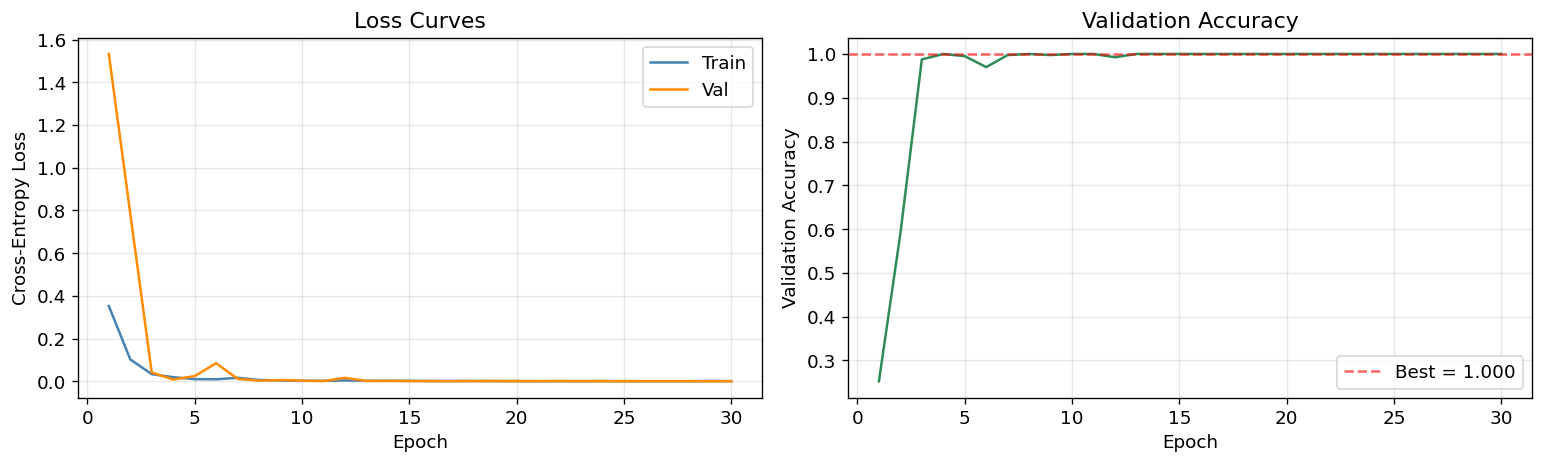

Best val accuracy: 1.0000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='darkorange')
axes[0].set(xlabel='Epoch', ylabel='Cross-Entropy Loss', title='Loss Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'], color='seagreen')
axes[1].axhline(y=max(history['val_acc']), color='red', linestyle='--', alpha=0.6,
                label=f'Best = {max(history["val_acc"]):.3f}')
axes[1].set(xlabel='Epoch', ylabel='Validation Accuracy', title='Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/03_training_curves.png', bbox_inches='tight')
plt.show()
print(f'Best val accuracy: {max(history["val_acc"]):.4f}')

## 3.3 Evaluation on Full Validation Set

In [4]:
from torch.utils.data import TensorDataset, DataLoader, random_split

X_all = torch.tensor(specs,  dtype=torch.float32)
y_all = torch.tensor(labels, dtype=torch.long)
dataset = TensorDataset(X_all, y_all)

n_val   = int(0.2 * len(dataset))
n_train = len(dataset) - n_val
_, val_ds = random_split(dataset, [n_train, n_val],
                          generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_ds, batch_size=128)

model.eval()
all_preds, all_probs, all_true = [], [], []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

print('Classification Report:')
print(classification_report(all_true, all_preds, target_names=['Clear', 'Blocked']))

Classification Report:


              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00       101
     Blocked       1.00      1.00      1.00       299

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 3.4 Confusion Matrix & ROC Curve

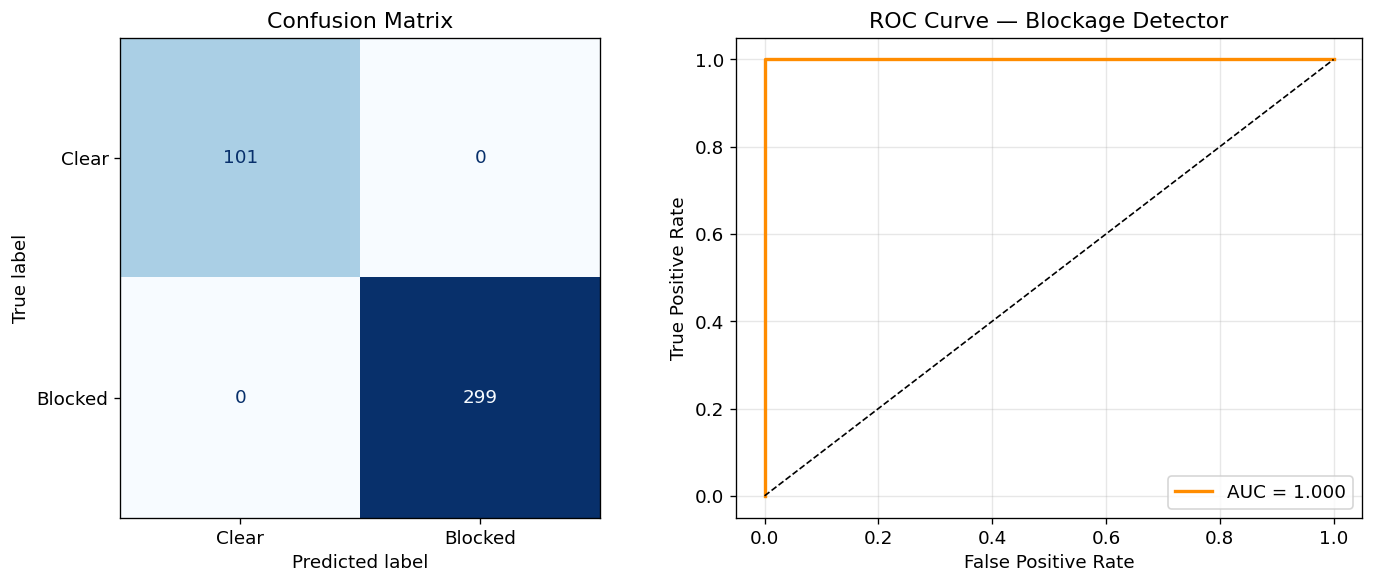

ROC-AUC: 1.0000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Clear', 'Blocked'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve — Blockage Detector')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/03_evaluation.png', bbox_inches='tight')
plt.show()
print(f'ROC-AUC: {roc_auc:.4f}')

## 3.5 Classical DSP Baseline Comparison

We compare the CNN against the classical peak-detection approach from Notebook 02.
The DSP baseline labels a signal as blocked if any echo peak is detected.

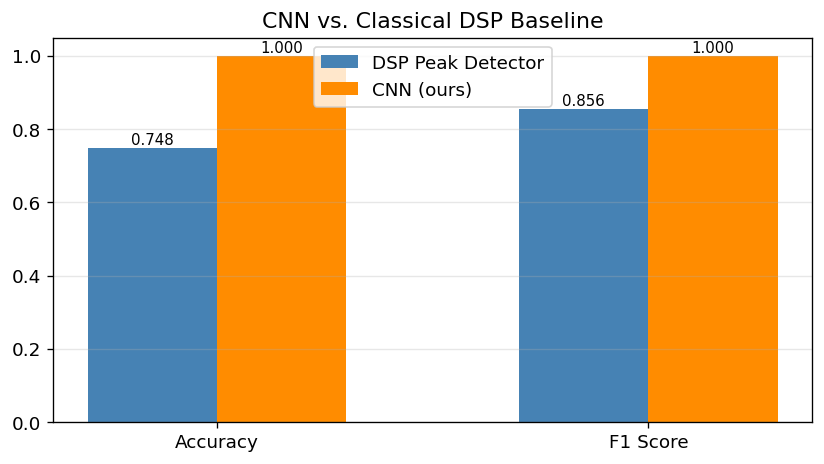

DSP Baseline — Accuracy: 0.7475  F1: 0.8555
CNN Detector — Accuracy: 1.0000  F1: 1.0000


In [6]:
# Get the validation indices (same split as model training)
val_indices = list(val_ds.indices)
val_signals = signals[val_indices]
val_labels  = labels[val_indices]

# DSP predictions
dsp_preds = []
for sig in val_signals:
    peak_t, _ = detect_echo_peaks(sig, fs=44_100, min_prominence=0.04)
    dsp_preds.append(1 if len(peak_t) > 0 else 0)
dsp_preds = np.array(dsp_preds)

from sklearn.metrics import accuracy_score, f1_score

cnn_acc = accuracy_score(all_true, all_preds)
dsp_acc = accuracy_score(val_labels, dsp_preds)
cnn_f1  = f1_score(all_true, all_preds)
dsp_f1  = f1_score(val_labels, dsp_preds)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [dsp_acc, dsp_f1], w, label='DSP Peak Detector', color='steelblue')
ax.bar(x + w/2, [cnn_acc, cnn_f1], w, label='CNN (ours)',         color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'])
ax.set_ylim(0, 1.05)
ax.set_title('CNN vs. Classical DSP Baseline')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/plots/03_cnn_vs_dsp.png', bbox_inches='tight')
plt.show()

print(f'DSP Baseline — Accuracy: {dsp_acc:.4f}  F1: {dsp_f1:.4f}')
print(f'CNN Detector — Accuracy: {cnn_acc:.4f}  F1: {cnn_f1:.4f}')